### **Library**

In [1]:
# =========================================
# LIBRARY & DEPENDENCIES
# =========================================

# 1. Pip Installations
!pip install ImageHash pillow -q

# 2. Standard & Utility Libraries
import os
import random
import shutil
import zipfile
import datetime
import warnings
import contextlib
warnings.filterwarnings('ignore')

# 3. Data Processing & Image Hashing
import numpy as np
import pandas as pd
import imagehash
from PIL import Image
import PIL # Added for version print

# 4. Google Colab & UI Widgets
from google.colab import drive, files
import ipywidgets as widgets
from IPython.display import display, clear_output

# 5. Visualization
import matplotlib.pyplot as plt
import matplotlib # Added for version print
import matplotlib.image as mpimg
import seaborn as sns

# 6. Machine Learning & Preprocessing
import sklearn # Added for version print
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# 7. Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import mixed_precision

# =========================================
# SETUP ENVIRONMENT
# =========================================
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow    : {tf.__version__}")
print(f"Pandas        : {pd.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"Seaborn       : {sns.__version__}")
print(f"Pillow (PIL)  : {PIL.__version__}")
print(f"Scikit-Learn  : {sklearn.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.8 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow    : 2.20.0
Pandas        : 2.2.2
NumPy         : 2.0.2
Matplotlib    : 3.10.0
Seaborn       : 0.13.2
Pillow (PIL)  : 11.3.0
Scikit-Learn  : 1.6.1


# **FASE: DATA UNDERSTANDING**

### **Collect Data**

In [2]:
# =========================================
# MOUNT DRIVE & COLLECT DATA
# =========================================
drive.mount('/content/drive')
zip_file = '/content/drive/MyDrive/Colab Notebooks/dataset/archive.zip'
extract_path = '/content/dataset'
print("=" * 60)
print("CHECKING ZIP FILE")
print("=" * 60)
if os.path.exists(zip_file):
    print(f"ZIP File Found    : {os.path.basename(zip_file)}")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Status            : Dataset Extraction Completed")
    print("\n" + "=" * 60)
    print("EXTRACTED FOLDER")
    print("=" * 60)
    folders = os.listdir(extract_path)
    for folder in folders:
        print(f"Folder Name       : {folder}")
    dataset_path = extract_path
    print("\n" + "=" * 60)
    print("DATASET PATH")
    print("=" * 60)
    print(f"Dataset Location  : {dataset_path}")
else:
    print("ZIP File Not Found. Silakan periksa kembali struktur folder di Google Drive Anda.")

Mounted at /content/drive
CHECKING ZIP FILE
ZIP File Found    : archive.zip
Status            : Dataset Extraction Completed

EXTRACTED FOLDER
Folder Name       : archive

DATASET PATH
Dataset Location  : /content/dataset


### **Describe data**

In [3]:
# =========================================
# DATASET INFORMATION
# =========================================
main_dataset_path = '/content/dataset/archive'
print("=" * 65)
print("DATASET SOURCE")
print("=" * 65)
print(f"Dataset Path : {main_dataset_path}")
print("\n" + "=" * 65)
print("DATASET FOLDER STRUCTURE")
print("=" * 65)
for root, dirs, files in os.walk(main_dataset_path):
    level = root.replace(main_dataset_path, '').count(os.sep)
    indent = '    ' * level
    folder_name = os.path.basename(root)
    print(f"{indent}|-- {folder_name}")

DATASET SOURCE
Dataset Path : /content/dataset/archive

DATASET FOLDER STRUCTURE
|-- archive
    |-- dataset
        |-- freshbanana
        |-- Fruits
        |-- rottencapsicum
        |-- rottenbanana
        |-- freshpotato
        |-- rottenapples
        |-- freshtomato
        |-- rottenpotato
        |-- freshbittergroud
        |-- Vegetables
        |-- rottenokra
        |-- freshcucumber
        |-- rottenbittergroud
        |-- freshoranges
        |-- rottencucumber
        |-- freshapples
        |-- freshokra
        |-- rottenoranges
        |-- freshcapsicum
        |-- rottentomato


In [4]:
# ============================================================
# METADATA COLLECTION
# ============================================================
import os
import pandas as pd
from IPython.display import display
main_dataset_path = '/content/dataset/archive/dataset'
all_classes = set()
unique_commodities = set()
grand_total = 0
allowed_extensions = ('.png', '.jpg', '.jpeg')
if os.path.exists(main_dataset_path):
    for class_folder in sorted(os.listdir(main_dataset_path)):
        class_path = os.path.join(main_dataset_path, class_folder)
        if class_folder in ['Fruits', 'Vegetables'] or not os.path.isdir(class_path):
            continue
        files = [f for f in os.listdir(class_path) if f.lower().endswith(allowed_extensions)]
        grand_total += len(files)
        all_classes.add(class_folder)
        commodity = (
            class_folder
            .replace('fresh', '')
            .replace('rotten', '')
            .replace('Fresh', '')
            .replace('Rotten', '')
            .capitalize()
        )
        unique_commodities.add(commodity)
    info_data = [
        {
            "No": 1,
            "Metric": "Classes",
            "Total": len(all_classes),
            "Description": ", ".join(sorted(all_classes))
        },
        {
            "No": 2,
            "Metric": "Images",
            "Total": grand_total,
            "Description": "Grand total of valid images within the dataset"
        },
        {
            "No": 3,
            "Metric": "Unique Commodities",
            "Total": len(unique_commodities),
            "Description": ", ".join(sorted(unique_commodities))
        }
    ]
    df_info = pd.DataFrame(info_data)
    styled_info = (df_info.style.hide(axis='index')
        .set_properties(subset=['Metric', 'Description'], **{'text-align': 'left', 'padding-left': '10px'})
        .set_properties(subset=['No', 'Total'], **{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'table', 'props': [('width', '750px'), ('border-collapse', 'collapse'), ('border', '1px solid black')]},
            {'selector': 'th, td', 'props': [('border', '1px solid black'), ('padding', '8px'), ('text-align', 'left')]},
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'left')]}
        ]))
    display(styled_info)
else:
    print(f"Path not found: {main_dataset_path}. Please recheck your folder structure.")

No,Metric,Total,Description
1,Classes,18,"freshapples, freshbanana, freshbittergroud, freshcapsicum, freshcucumber, freshokra, freshoranges, freshpotato, freshtomato, rottenapples, rottenbanana, rottenbittergroud, rottencapsicum, rottencucumber, rottenokra, rottenoranges, rottenpotato, rottentomato"
2,Images,30357,Grand total of valid images within the dataset
3,Unique Commodities,9,"Apples, Banana, Bittergroud, Capsicum, Cucumber, Okra, Oranges, Potato, Tomato"


In [5]:
# ============================================================
# COMMODITY AND CLASS
# ============================================================
main_dataset_path = '/content/dataset/archive/dataset'
data_rows = []
row_number = 1
allowed_extensions = ('.png', '.jpg', '.jpeg')
if os.path.exists(main_dataset_path):
    for class_name in sorted(os.listdir(main_dataset_path)):
        class_path = os.path.join(main_dataset_path, class_name)
        if class_name in ['Fruits', 'Vegetables'] or not os.path.isdir(class_path):
            continue
        total_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(allowed_extensions)
        ])
        commodity = (
            class_name
            .replace('fresh', '')
            .replace('rotten', '')
            .replace('Fresh', '')
            .replace('Rotten', '')
            .capitalize()
        )
        data_rows.append({
            'No': row_number,
            'Class Name': class_name,
            'Unique Commodity': commodity,
            'Total Images': total_images
        })
        row_number += 1
    combined_df = pd.DataFrame(data_rows)
    grand_total = combined_df['Total Images'].sum()
    total_row = {
        'No': '-',
        'Class Name': 'TOTAL',
        'Unique Commodity': '-',
        'Total Images': grand_total
    }
    combined_df = pd.concat([combined_df, pd.DataFrame([total_row])], ignore_index=True)
    combined_table = (
        combined_df.style.hide(axis='index')
        .set_properties(subset=['No', 'Total Images'], **{'text-align': 'center'})
        .set_properties(subset=['Class Name', 'Unique Commodity'], **{'text-align': 'left'})
        .set_table_styles([
            {
                'selector': 'table',
                'props': [
                    ('width', '650px'),
                    ('border-collapse', 'collapse'),
                    ('border', '1px solid black')
                ]
            },
            {
                'selector': 'th, td',
                'props': [
                    ('border', '1px solid black'),
                    ('padding', '8px')
                ]
            },
            {
                'selector': 'th',
                'props': [
                    ('font-weight', 'bold'),
                    ('text-align', 'center')
                ]
            }
        ])
    )
    display(combined_table)
else:
    print(f"Path tidak ditemukan: {main_dataset_path}. Silakan periksa kembali struktur folder Anda.")

No,Class Name,Unique Commodity,Total Images
1,freshapples,Apples,3215
2,freshbanana,Banana,3360
3,freshbittergroud,Bittergroud,327
4,freshcapsicum,Capsicum,990
5,freshcucumber,Cucumber,775
6,freshokra,Okra,1005
7,freshoranges,Oranges,1854
8,freshpotato,Potato,806
9,freshtomato,Tomato,2113
10,rottenapples,Apples,4236


In [6]:
# ============================================================
# DATA UNDERSTANDING: FULL DATASET METADATA AUDIT & SUMMARY
# ============================================================
main_dataset_path = '/content/dataset/archive/dataset'
allowed_extensions = ('.png', '.jpg', '.jpeg')
standard_dim_count = 0
non_standard_dim_count = 0
total_scanned_files = 0
color_mode_counts = {'Corrupt/Error': 0}
if os.path.exists(main_dataset_path):
    for class_name in sorted(os.listdir(main_dataset_path)):
        class_path = os.path.join(main_dataset_path, class_name)
        if class_name in ['Fruits', 'Vegetables'] or not os.path.isdir(class_path):
            continue
        files = os.listdir(class_path)
        for file_name in files:
            if file_name.lower().endswith(allowed_extensions):
                file_path = os.path.join(class_path, file_name)
                total_scanned_files += 1
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        mode = img.mode
                    if width == 224 and height == 224:
                        standard_dim_count += 1
                    else:
                        non_standard_dim_count += 1
                    color_mode_counts[mode] = color_mode_counts.get(mode, 0) + 1
                except Exception as e:
                    color_mode_counts['Corrupt/Error'] = color_mode_counts.get('Corrupt/Error', 0) + 1
    pct_standard = (standard_dim_count / total_scanned_files * 100) if total_scanned_files > 0 else 0
    pct_non_standard = (non_standard_dim_count / total_scanned_files * 100) if total_scanned_files > 0 else 0
    print("===========================================================================")
    print("SUMMARY (IMAGE FORMAT)")
    print("===========================================================================")
    print(f" - 224 x 224 pixels               : {standard_dim_count:<5} images ({pct_standard:.2f}%)")
    print(f" - Non 224 x 224 pixels           : {non_standard_dim_count:<5} images ({pct_non_standard:.2f}%)")
    print("\n===========================================================================")
    print("SUMMARY OF DETECTED COLOR MODES")
    print("===========================================================================")
    for mode, count in sorted(color_mode_counts.items()):
        pct_mode = (count / total_scanned_files * 100) if total_scanned_files > 0 else 0
        print(f" - {mode:<30} : {count:<5} images ({pct_mode:.2f}%)")
    print("===========================================================================")
else:
    print(f"Path not found: {main_dataset_path}. Please recheck your folder structure.")

SUMMARY (IMAGE FORMAT)
 - 224 x 224 pixels               : 0     images (0.00%)
 - Non 224 x 224 pixels           : 30357 images (100.00%)

SUMMARY OF DETECTED COLOR MODES
 - Corrupt/Error                  : 0     images (0.00%)
 - RGB                            : 28109 images (92.59%)
 - RGBA                           : 2248  images (7.41%)


### **Explore data**

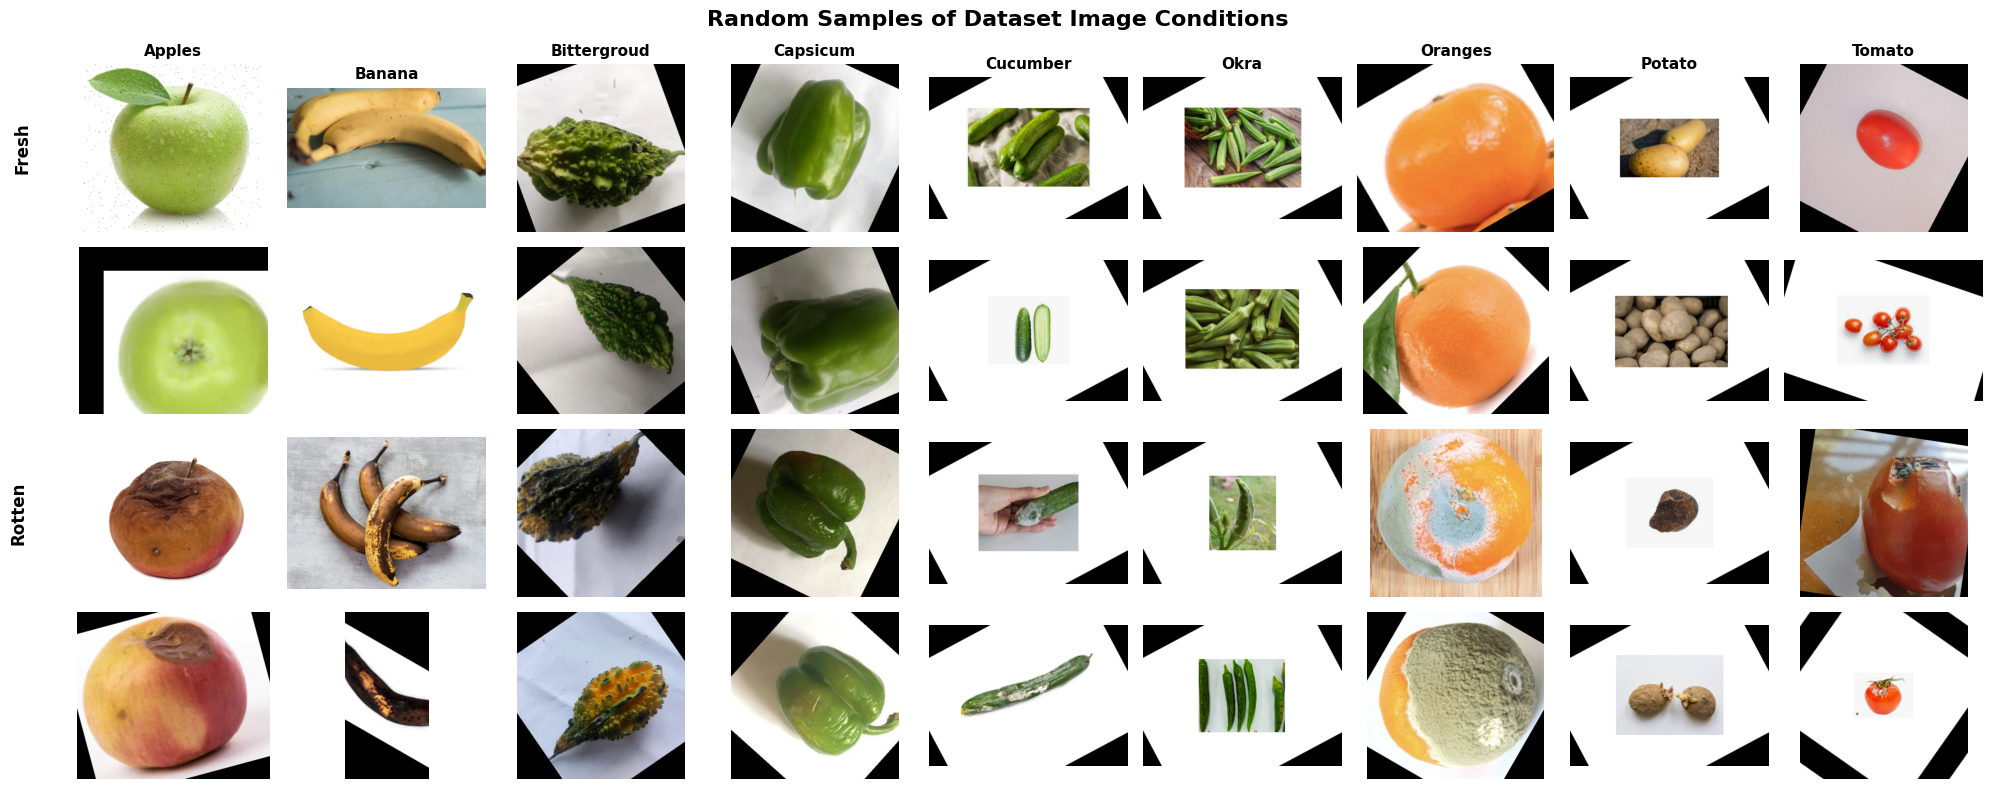

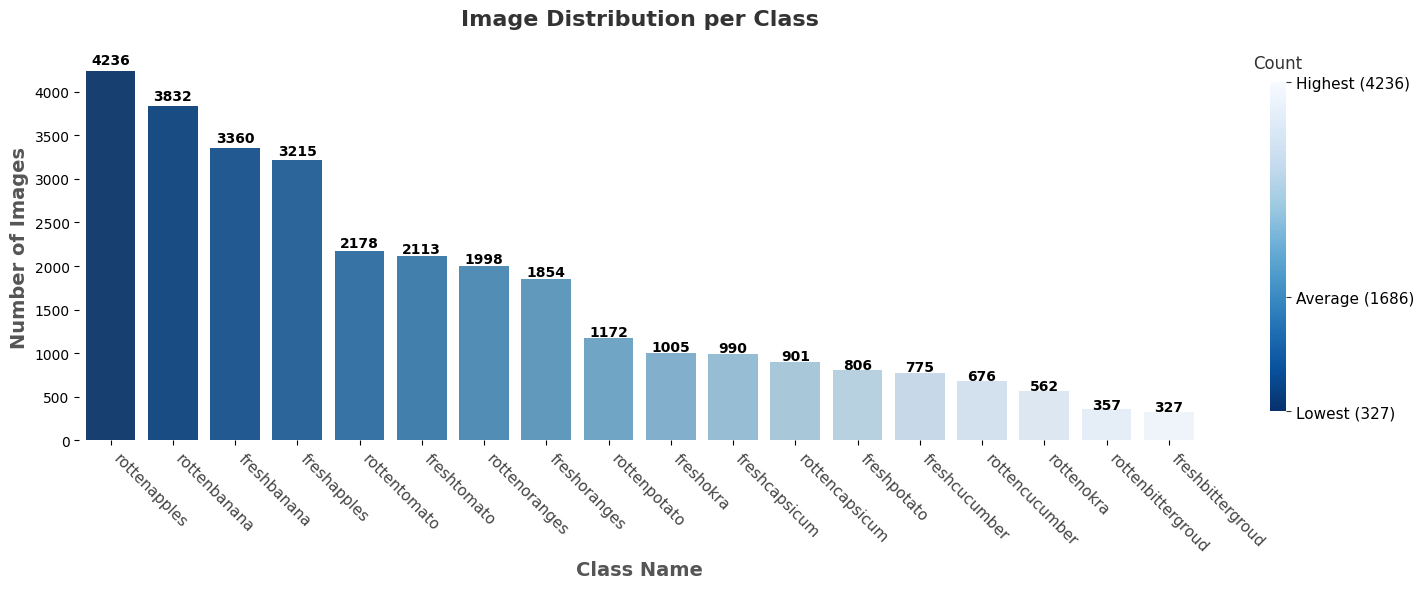

In [7]:
# ============================================================
# VISUALIZATION: RANDOM SAMPLES & DATA DISTRIBUTION
# ============================================================
main_dataset_path = '/content/dataset/archive/dataset'
allowed_extensions = ('.png', '.jpg', '.jpeg')
class_data = {}
if os.path.exists(main_dataset_path):
    for class_name in sorted(os.listdir(main_dataset_path)):
        class_path = os.path.join(main_dataset_path, class_name)
        if class_name in ['Fruits', 'Vegetables'] or not os.path.isdir(class_path):
            continue
        files = [f for f in os.listdir(class_path) if f.lower().endswith(allowed_extensions)]
        class_data[class_name] = files
    unique_commodities = sorted(list(set([
        f.replace('fresh', '').replace('rotten', '').replace('Fresh', '').replace('Rotten', '').capitalize()
        for f in class_data.keys()
    ])))

    # ==========================================
    # PART A: DISPLAY RANDOM IMAGE SAMPLES GRID
    # ==========================================
    fig_img = plt.figure(figsize=(20, 8))
    for col, comm in enumerate(unique_commodities):
        for row, condition in enumerate(['fresh', 'rotten']):
            matched_class = None
            for actual_class in class_data.keys():
                if actual_class.lower() == (condition + comm).lower():
                    matched_class = actual_class
                    break
            if matched_class and class_data[matched_class]:
                files = class_data[matched_class]
                samples = random.sample(files, min(len(files), 2))
                for i, img_file in enumerate(samples):
                    ax = plt.subplot2grid((4, len(unique_commodities)), (row * 2 + i, col))
                    img = mpimg.imread(os.path.join(main_dataset_path, matched_class, img_file))
                    ax.imshow(img)
                    ax.axis('off')
                    if row == 0 and i == 0:
                        ax.set_title(comm, fontsize=11, fontweight='bold')
                    if col == 0 and i == 0:
                        ax.text(-0.3, 0.5, condition.capitalize(), transform=ax.transAxes,
                                fontsize=12, fontweight='bold', va='center', ha='right', rotation=90)
    plt.suptitle("Random Samples of Dataset Image Conditions", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")

# ==========================================
# PART B: DISPLAY DATA DISTRIBUTION CHART (TANPA GRID)
# ==========================================
df_stats = pd.DataFrame({
    'Class Name': list(class_data.keys()),
    'Image Count': [len(v) for v in class_data.values()]
}).sort_values(by='Image Count', ascending=False)
highest_count = df_stats['Image Count'].max()
average_count = round(df_stats['Image Count'].mean())
lowest_count = df_stats['Image Count'].min()
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=df_stats, x='Class Name', y='Image Count', palette='Blues_r')
for index, row in enumerate(df_stats.itertuples()):
    plt.text(index, row._2 + (row._2 * 0.02), str(row._2), color='black', ha="center", fontsize=10, fontweight='bold')
plt.title('Image Distribution per Class', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Class Name', fontsize=14, fontweight='bold', color='#555555')
plt.ylabel('Number of Images', fontsize=14, fontweight='bold', color='#555555')
plt.xticks(rotation=-45, ha='left', fontsize=11, color='#444444')
norm = plt.Normalize(lowest_count, highest_count)
sm = plt.cm.ScalarMappable(cmap='Blues_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.85, pad=0.05)
cbar.ax.set_title('Count', fontsize=12, color='#333333', pad=10)
cbar.set_ticks([highest_count, average_count, lowest_count])
cbar.set_ticklabels([f'Highest ({highest_count})', f'Average ({average_count})', f'Lowest ({lowest_count})'])
cbar.ax.tick_params(labelsize=11, color='#333333')
cbar.outline.set_visible(False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# **FASE: DATA PREPARATION**

## **Clean Data**

In [8]:
# ==============================================================================
# DATA UNDERSTANDING: IMAGE DUPLICATION REMOVAL (ALIGNED PROCESS VERSION)
# ==============================================================================
main_dataset_path = '/content/dataset/archive/dataset'
allowed_extensions = ('.png', '.jpg', '.jpeg', '.webp', '.bmp')
reject_dir = '/content/dataset/archive/reject'
os.makedirs(reject_dir, exist_ok=True)
def saring_dan_bersihkan_folder(path_folder_sekarang, nama_kelas):
    """Mendeteksi gambar duplikat, memindahkan ke reject, dan merapikan folder."""
    image_hashes = {}
    for filename in os.listdir(path_folder_sekarang):
        if filename.lower().endswith(allowed_extensions):
            file_path = os.path.join(path_folder_sekarang, filename)
            try:
                with Image.open(file_path) as img:
                    hash_value = imagehash.phash(img)
                    if hash_value not in image_hashes:
                        image_hashes[hash_value] = []
                    image_hashes[hash_value].append(file_path)
            except Exception as e:
                print(f"\n  [ERROR] Gagal membaca {filename}: {e}")
    if not image_hashes:
        return 0, 0
    temp_output_dir = os.path.join(path_folder_sekarang, "temp_proses")
    os.makedirs(temp_output_dir, exist_ok=True)
    jumlah_duplikat_dibuang = 0
    for index, (hash_val, file_paths) in enumerate(image_hashes.items(), start=1):
        kode_sampel = f"S{index}"
        sampel_asli = file_paths[0]
        ekstensi = os.path.splitext(sampel_asli)[1]
        nama_sampel_baru = f"{kode_sampel}{ekstensi}"
        shutil.copy(sampel_asli, os.path.join(temp_output_dir, nama_sampel_baru))
        if len(file_paths) > 1:
            for urutan, duplikat_path in enumerate(file_paths[1:], start=1):
                nama_reject_baru = f"reject_{nama_kelas}_{kode_sampel}_{urutan:02d}{ekstensi}"
                shutil.move(duplikat_path, os.path.join(reject_dir, nama_reject_baru))
                jumlah_duplikat_dibuang += 1
        if os.path.exists(sampel_asli):
            os.remove(sampel_asli)
    for filename in os.listdir(path_folder_sekarang):
        file_path = os.path.join(path_folder_sekarang, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)
    for file_baru in os.listdir(temp_output_dir):
        shutil.move(os.path.join(temp_output_dir, file_baru), path_folder_sekarang)
    os.rmdir(temp_output_dir)
    return len(image_hashes), jumlah_duplikat_dibuang
if os.path.exists(main_dataset_path):
    print("=" * 75)
    print("DATA CLEANING: IMAGE DUPLICATE DETECTION & REMOVAL")
    print("=" * 75)
    print("Processing Folders:")
    grand_total_unique = 0
    grand_total_rejected = 0
    total_folders_processed = 0
    all_items = sorted([
        d for d in os.listdir(main_dataset_path)
        if os.path.isdir(os.path.join(main_dataset_path, d)) and d not in ['Fruits', 'Vegetables']
    ])
    for item in all_items:
        item_path = os.path.join(main_dataset_path, item)
        folder_label = f" -> [{item}]".ljust(25)
        jumlah_unik, jumlah_reject = saring_dan_bersihkan_folder(item_path, item)
        print(f"{folder_label} : Unique: {jumlah_unik} | Duplicates Moved: {jumlah_reject}")
        grand_total_unique += jumlah_unik
        grand_total_rejected += jumlah_reject
        total_folders_processed += 1
    # ==============================================================================
    # MENAMPILKAN RINGKASAN AKHIR (SUMMARY REPORT)
    # ==============================================================================
    print("-" * 75)
    print("SUMMARY REPORT")
    print("-" * 75)
    print(f"Total Folders Cleaned               : {total_folders_processed}")
    print(f"Total Unique Images Retained        : {grand_total_unique}")
    print(f"Total Duplicate Images Removed      : {grand_total_rejected}")
    print(f"Reject Destination Folder           : {reject_dir}")
    print(f"Status                              : Data cleaning successfully completed!")
    print("=" * 75)
else:
    print(f"[ERROR] Path tidak ditemukan: {main_dataset_path}")

DATA CLEANING: IMAGE DUPLICATE DETECTION & REMOVAL
Processing Folders:
 -> [freshapples]         : Unique: 1894 | Duplicates Moved: 1321
 -> [freshbanana]         : Unique: 1799 | Duplicates Moved: 1561
 -> [freshbittergroud]    : Unique: 326 | Duplicates Moved: 1
 -> [freshcapsicum]       : Unique: 990 | Duplicates Moved: 0
 -> [freshcucumber]       : Unique: 274 | Duplicates Moved: 501
 -> [freshokra]           : Unique: 612 | Duplicates Moved: 393
 -> [freshoranges]        : Unique: 1698 | Duplicates Moved: 156
 -> [freshpotato]         : Unique: 530 | Duplicates Moved: 276
 -> [freshtomato]         : Unique: 1773 | Duplicates Moved: 340
 -> [rottenapples]        : Unique: 2682 | Duplicates Moved: 1554
 -> [rottenbanana]        : Unique: 2473 | Duplicates Moved: 1359
 -> [rottenbittergroud]   : Unique: 356 | Duplicates Moved: 1
 -> [rottencapsicum]      : Unique: 901 | Duplicates Moved: 0
 -> [rottencucumber]      : Unique: 411 | Duplicates Moved: 265
 -> [rottenokra]          : Uni

## **Construct Data**

In [9]:
# ============================================================
# DATA PREPROCESSING: RESIZE, COLOR CONVERSION (RGB), & NORMALIZATION
# ============================================================
datagen = ImageDataGenerator(
    rescale=1./255
)
with open(os.devnull, 'w') as devnull:
    with contextlib.redirect_stdout(devnull):
        dataset_generator = datagen.flow_from_directory(
            directory=main_dataset_path,
            target_size=(224, 224),
            color_mode='rgb',
            batch_size=32,
            class_mode='categorical',
            shuffle=True
        )
print("===========================================================================")
print("VERIFIKASI HASIL PREPROCESSING")
print("===========================================================================")
print(f" Total gambar berhasil diproses : {dataset_generator.samples}")
print(f" Jumlah kelas yang ditemukan    : {dataset_generator.num_classes}")
print(f" Ukuran input gambar (Target)   : {dataset_generator.image_shape}")
print("===========================================================================")

VERIFIKASI HASIL PREPROCESSING
 Total gambar berhasil diproses : 20986
 Jumlah kelas yang ditemukan    : 20
 Ukuran input gambar (Target)   : (224, 224, 3)


## **Split Data**

In [10]:
# ============================================================
# DATA SPLITTING: 80% TRAINING, 10% VALIDATION, 10% TESTING
# ============================================================
all_filepaths = []
all_labels = []
if os.path.exists(main_dataset_path):
    for class_name in sorted(os.listdir(main_dataset_path)):
        class_path = os.path.join(main_dataset_path, class_name)
        if class_name in ['Fruits', 'Vegetables'] or not os.path.isdir(class_path):
            continue
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(allowed_extensions):
                all_filepaths.append(os.path.join(class_path, file_name))
                all_labels.append(class_name)
df = pd.DataFrame({'filepath': all_filepaths, 'label': all_labels})
train_df, remaining_df = train_test_split(
    df, train_size=0.80, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    remaining_df, train_size=0.50, stratify=remaining_df['label'], random_state=42
)
datagen = ImageDataGenerator(rescale=1./255)
with open(os.devnull, 'w') as devnull:
    with contextlib.redirect_stdout(devnull):
        train_generator = datagen.flow_from_dataframe(
            dataframe=train_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=True
        )
        val_generator = datagen.flow_from_dataframe(
            dataframe=val_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=False
        )
        test_generator = datagen.flow_from_dataframe(
            dataframe=test_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=False
        )
print("===========================================================================")
print("SUMMARY DATA SPLITTING (80:10:10)")
print("===========================================================================")
print(f" Total gambar Training set (80%) : {len(train_df):<5} images")
print(f" Total gambar Validation set(10%): {len(val_df):<5} images")
print(f" Total gambar Testing set (10%)  : {len(test_df):<5} images")
print("===========================================================================")

SUMMARY DATA SPLITTING (80:10:10)
 Total gambar Training set (80%) : 16788 images
 Total gambar Validation set(10%): 2099  images
 Total gambar Testing set (10%)  : 2099  images


In [11]:
# ============================================================
# EXPORT TESTING SET KE FOLDER ZIP
# ============================================================
import shutil
import os
from google.colab import files
output_folder = 'testing_set_export'
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)
print("Sedang menyalin file ke folder testing_set_export...")
for index, row in test_df.iterrows():
    class_folder = os.path.join(output_folder, row['label'])
    os.makedirs(class_folder, exist_ok=True)
    shutil.copy2(row['filepath'], os.path.join(class_folder, os.path.basename(row['filepath'])))
zip_filename = 'testing_set.zip'
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', output_folder)
print(f"Selesai! Folder '{output_folder}' telah dibuat dan dikompres menjadi '{zip_filename}'.")
files.download(zip_filename)

Sedang menyalin file ke folder testing_set_export...
Selesai! Folder 'testing_set_export' telah dibuat dan dikompres menjadi 'testing_set.zip'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Augmentasi Data**

In [12]:
# ============================================================
# DATA PREPROCESSING: RESIZE, NORMALIZATION & FULL DATA AUGMENTATION
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)
with open(os.devnull, 'w') as devnull:
    with contextlib.redirect_stdout(devnull):
        train_generator = train_datagen.flow_from_dataframe(
            dataframe=train_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=True
        )
        val_generator = val_test_datagen.flow_from_dataframe(
            dataframe=val_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=False
        )
        test_generator = val_test_datagen.flow_from_dataframe(
            dataframe=test_df, x_col='filepath', y_col='label',
            target_size=(224, 224), color_mode='rgb', batch_size=32, class_mode='categorical', shuffle=False
        )
print("===========================================================================")
print("VERIFIKASI DATA SETELAH SPLIT & AUGMENTASI")
print("===========================================================================")
print(f" Total gambar Training set (Augmented) : {train_generator.samples}")
print(f" Total gambar Validation set(Original) : {val_generator.samples}")
print(f" Total gambar Testing set (Original)   : {test_generator.samples}")
print(f" Ukuran akhir gambar untuk Model       : {train_generator.image_shape}")
print("===========================================================================")

VERIFIKASI DATA SETELAH SPLIT & AUGMENTASI
 Total gambar Training set (Augmented) : 16788
 Total gambar Validation set(Original) : 2099
 Total gambar Testing set (Original)   : 2099
 Ukuran akhir gambar untuk Model       : (224, 224, 3)


# **FASE: MODELING**

## **Select Modeling Technique**

In [13]:
# ============================================================
# MODEL DEVELOPMENT: MOBILENETV2 ARCHITECTURE (TRANSFER LEARNING)
# ============================================================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
num_classes = len(train_df['label'].unique())
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)
print("===========================================================================")
print("RINGKASAN ARSITEKTUR MODEL")
print("===========================================================================")
print(f" Arsitektur Utama (Base)     : MobileNetV2")
print(f" Status Base Model           : Frozen (Tidak Dilatih Ulang)")
print(f" Lapisan Pooling             : GlobalAveragePooling2D")
print(f" Lapisan Tersembunyi (Dense) : 1 Layer (256 Unit, Aktivasi ReLU)")
print(f" Lapisan Regulasi            : Dropout (Rate: 0.4)")
print(f" Lapisan Output (Dense)      : {num_classes} Unit, Aktivasi Softmax")
print("===========================================================================")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
RINGKASAN ARSITEKTUR MODEL
 Arsitektur Utama (Base)     : MobileNetV2
 Status Base Model           : Frozen (Tidak Dilatih Ulang)
 Lapisan Pooling             : GlobalAveragePooling2D
 Lapisan Tersembunyi (Dense) : 1 Layer (256 Unit, Aktivasi ReLU)
 Lapisan Regulasi            : Dropout (Rate: 0.4)
 Lapisan Output (Dense)      : 18 Unit, Aktivasi Softmax


## **Compile Model**

In [14]:
# ============================================================
# MODEL COMPILATION (UPDATED FOR 18 CLASSES)
# ============================================================
learning_rate = 0.0001
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
num_classes = len(train_df['label'].unique())
print("===========================================================================")
print("VERIFIKASI KOMPILASI MODEL TERBARU")
print("===========================================================================")
print(f" Optimizer     : Adam (Learning Rate: {learning_rate})")
print(f" Loss Function : Categorical Crossentropy")
print(f" Metrik Pantau : Accuracy")
print(f" Total Kelas   : {num_classes} Kelas (Terbaca Otomatis)")
print(f" Status Model  : Siap untuk Tahap Training (Pelatihan)")
print("===========================================================================")

VERIFIKASI KOMPILASI MODEL TERBARU
 Optimizer     : Adam (Learning Rate: 0.0001)
 Loss Function : Categorical Crossentropy
 Metrik Pantau : Accuracy
 Total Kelas   : 18 Kelas (Terbaca Otomatis)
 Status Model  : Siap untuk Tahap Training (Pelatihan)


## **Konfigurasi Callback**

In [15]:
# ============================================================
# MODEL CONFIGURATION: CALLBACKS (EARLY STOPPING & CHECKPOINT)
# ============================================================
checkpoint_dir = '/content/saved_models'
os.makedirs(checkpoint_dir, exist_ok=True)
model_save_path = os.path.join(checkpoint_dir, 'best_model.keras')
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
model_checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
callbacks_list = [early_stopping, model_checkpoint]
print("===========================================================================")
print("VERIFIKASI KONFIGURASI CALLBACKS")
print("===========================================================================")
print(f" Early Stopping     : Aktif (Monitor: val_loss, Patience: 5 Epochs)")
print(f" Model Checkpoint   : Aktif (Monitor: val_loss, Simpan Terbaik Saja)")
print(f" Lokasi Penyimpanan : {model_save_path}")
print(f" Status             : Callback Siap Digunakan pada Tahap Training")
print("===========================================================================")

VERIFIKASI KONFIGURASI CALLBACKS
 Early Stopping     : Aktif (Monitor: val_loss, Patience: 5 Epochs)
 Model Checkpoint   : Aktif (Monitor: val_loss, Simpan Terbaik Saja)
 Lokasi Penyimpanan : /content/saved_models/best_model.keras
 Status             : Callback Siap Digunakan pada Tahap Training


## **Class Weight**

In [16]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# HANDLING UNBALANCED DATA: COMPUTE CLASS WEIGHTS
# ============================================================
train_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(zip(np.unique(train_labels), class_weights))
print("===========================================================================")
print("BOBOT KELAS UNTUK MENGATASI UNBALANCED DATA")
print("===========================================================================")
for class_idx, weight in class_weight_dict.items():
    class_name = list(train_generator.class_indices.keys())[class_idx]
    print(f" Kelas {class_idx:<2} ({class_name:<15}) : Bobot Pelatihan -> {weight:.4f}")
print("===========================================================================")

BOBOT KELAS UNTUK MENGATASI UNBALANCED DATA
 Kelas 0  (freshapples    ) : Bobot Pelatihan -> 0.6156
 Kelas 1  (freshbanana    ) : Bobot Pelatihan -> 0.6481
 Kelas 2  (freshbittergroud) : Bobot Pelatihan -> 3.5734
 Kelas 3  (freshcapsicum  ) : Bobot Pelatihan -> 1.1776
 Kelas 4  (freshcucumber  ) : Bobot Pelatihan -> 4.2588
 Kelas 5  (freshokra      ) : Bobot Pelatihan -> 1.9034
 Kelas 6  (freshoranges   ) : Bobot Pelatihan -> 0.6868
 Kelas 7  (freshpotato    ) : Bobot Pelatihan -> 2.1997
 Kelas 8  (freshtomato    ) : Bobot Pelatihan -> 0.6577
 Kelas 9  (rottenapples   ) : Bobot Pelatihan -> 0.4348
 Kelas 10 (rottenbanana   ) : Bobot Pelatihan -> 0.4715
 Kelas 11 (rottenbittergroud) : Bobot Pelatihan -> 3.2725
 Kelas 12 (rottencapsicum ) : Bobot Pelatihan -> 1.2936
 Kelas 13 (rottencucumber ) : Bobot Pelatihan -> 2.8349
 Kelas 14 (rottenokra     ) : Bobot Pelatihan -> 7.9715
 Kelas 15 (rottenoranges  ) : Bobot Pelatihan -> 0.6379
 Kelas 16 (rottenpotato   ) : Bobot Pelatihan -> 1.5544
 

## **Training Model**

In [17]:
# ============================================================
# MODEL TRAINING (INITIAL TRAINING)
# ============================================================
print("===========================================================================")
print("MEMULAI PROSES TRAINING AWAL MODEL")
print("===========================================================================")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_list,
    class_weight=class_weight_dict,
    verbose=1
)
print("---------------------------------------------------------------------------")
print("PROSES TRAINING AWAL SELESAI")
print("===========================================================================")
print(f" Waktu Selesai  : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("===========================================================================")

MEMULAI PROSES TRAINING AWAL MODEL
Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.4532 - loss: 1.9304
Epoch 1: val_loss improved from None to 0.34667, saving model to /content/saved_models/best_model.keras

Epoch 1: finished saving model to /content/saved_models/best_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 389s 666ms/step - accuracy: 0.6480 - loss: 1.2342 - val_accuracy: 0.9019 - val_loss: 0.3467
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8453 - loss: 0.5397
Epoch 2: val_loss improved from 0.34667 to 0.21926, saving model to /content/saved_models/best_model.keras

Epoch 2: finished saving model to /content/saved_models/best_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 277s 528ms/step - accuracy: 0.8582 - loss: 0.5070 - val_accuracy: 0.9295 - val_loss: 0.2193
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8890 - loss: 0.4001
Epoch 3: val_loss improved from 0.21926 to 0.17581, saving model to /content/saved_models/best_model

## **Fine-Tuning**

In [18]:
# ============================================================
# MODEL FINE-TUNING
# ============================================================
import datetime
from tensorflow.keras.optimizers import Adam
print("===========================================================================")
print("PERSIAPAN PROSES FINE-TUNING")
print("===========================================================================")
base_model.trainable = True
fine_tune_at = 114
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
fine_tune_learning_rate = 0.00001
model.compile(
    optimizer=Adam(learning_rate=fine_tune_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f" Status Base Model           : Unfrozen pada {len(base_model.layers) - fine_tune_at} Layer Teratas")
print(f" Fine-Tuning Learning Rate   : {fine_tune_learning_rate}")
print("---------------------------------------------------------------------------")
print("MEMULAI PROSES TRAINING FINE-TUNING")
print("---------------------------------------------------------------------------")
fine_tune_epochs = 15
total_epochs = len(history.history['loss']) + fine_tune_epochs
history_fine = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=len(history.history['loss']),
    validation_data=val_generator,
    callbacks=callbacks_list,
    class_weight=class_weight_dict,
    verbose=1
)
print("---------------------------------------------------------------------------")
print("PROSES FINE-TUNING SELESAI")
print("===========================================================================")
print(f" Waktu Selesai  : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("===========================================================================")

PERSIAPAN PROSES FINE-TUNING
 Status Base Model           : Unfrozen pada 40 Layer Teratas
 Fine-Tuning Learning Rate   : 1e-05
---------------------------------------------------------------------------
MEMULAI PROSES TRAINING FINE-TUNING
---------------------------------------------------------------------------
Epoch 16/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.8176 - loss: 0.6051
Epoch 16: val_loss did not improve from 0.07733
525/525 ━━━━━━━━━━━━━━━━━━━━ 386s 640ms/step - accuracy: 0.8750 - loss: 0.4114 - val_accuracy: 0.9671 - val_loss: 0.1024
Epoch 17/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9222 - loss: 0.2576
Epoch 17: val_loss did not improve from 0.07733
525/525 ━━━━━━━━━━━━━━━━━━━━ 275s 523ms/step - accuracy: 0.9301 - loss: 0.2374 - val_accuracy: 0.9733 - val_loss: 0.0941
Epoch 18/30
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9455 - loss: 0.2000
Epoch 18: val_loss improved from 0.07733 to 0.06895, saving model to /content/s

# **FASE: EVALUATION**

## **Evaluate Results**

### **Visualisasi Metrik Evaluasi**

In [20]:
import pandas as pd
from sklearn.metrics import classification_report
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report['accuracy'] = df_report['recall']
df_report = df_report[['precision', 'recall', 'f1-score', 'accuracy', 'support']]
print("===========================================================================")
print("CLASSIFICATION REPORT DETIL PER KELAS")
print("===========================================================================")
print(df_report.round(2).to_string())
print("===========================================================================")

CLASSIFICATION REPORT DETIL PER KELAS
                   precision  recall  f1-score  accuracy  support
freshapples             0.99    0.99      0.99      0.99   189.00
freshbanana             1.00    1.00      1.00      1.00   180.00
freshbittergroud        1.00    1.00      1.00      1.00    32.00
freshcapsicum           1.00    1.00      1.00      1.00    99.00
freshcucumber           0.88    0.82      0.85      0.82    28.00
freshokra               0.95    0.93      0.94      0.93    61.00
freshoranges            1.00    1.00      1.00      1.00   170.00
freshpotato             1.00    0.89      0.94      0.89    53.00
freshtomato             0.99    0.99      0.99      0.99   178.00
rottenapples            0.99    1.00      0.99      1.00   269.00
rottenbanana            1.00    1.00      1.00      1.00   247.00
rottenbittergroud       1.00    1.00      1.00      1.00    36.00
rottencapsicum          1.00    1.00      1.00      1.00    90.00
rottencucumber          0.83    0.95  

CLASSIFICATION REPORT DETIL PER KELAS
                   precision  recall  f1-score  accuracy  support
freshapples             0.99    0.99      0.99      0.99   189.00
freshbanana             1.00    1.00      1.00      1.00   180.00
freshbittergroud        1.00    1.00      1.00      1.00    32.00
freshcapsicum           1.00    1.00      1.00      1.00    99.00
freshcucumber           0.88    0.82      0.85      0.82    28.00
freshokra               0.95    0.93      0.94      0.93    61.00
freshoranges            1.00    1.00      1.00      1.00   170.00
freshpotato             1.00    0.89      0.94      0.89    53.00
freshtomato             0.99    0.99      0.99      0.99   178.00
rottenapples            0.99    1.00      0.99      1.00   269.00
rottenbanana            1.00    1.00      1.00      1.00   247.00
rottenbittergroud       1.00    1.00      1.00      1.00    36.00
rottencapsicum          1.00    1.00      1.00      1.00    90.00
rottencucumber          0.83    0.95  

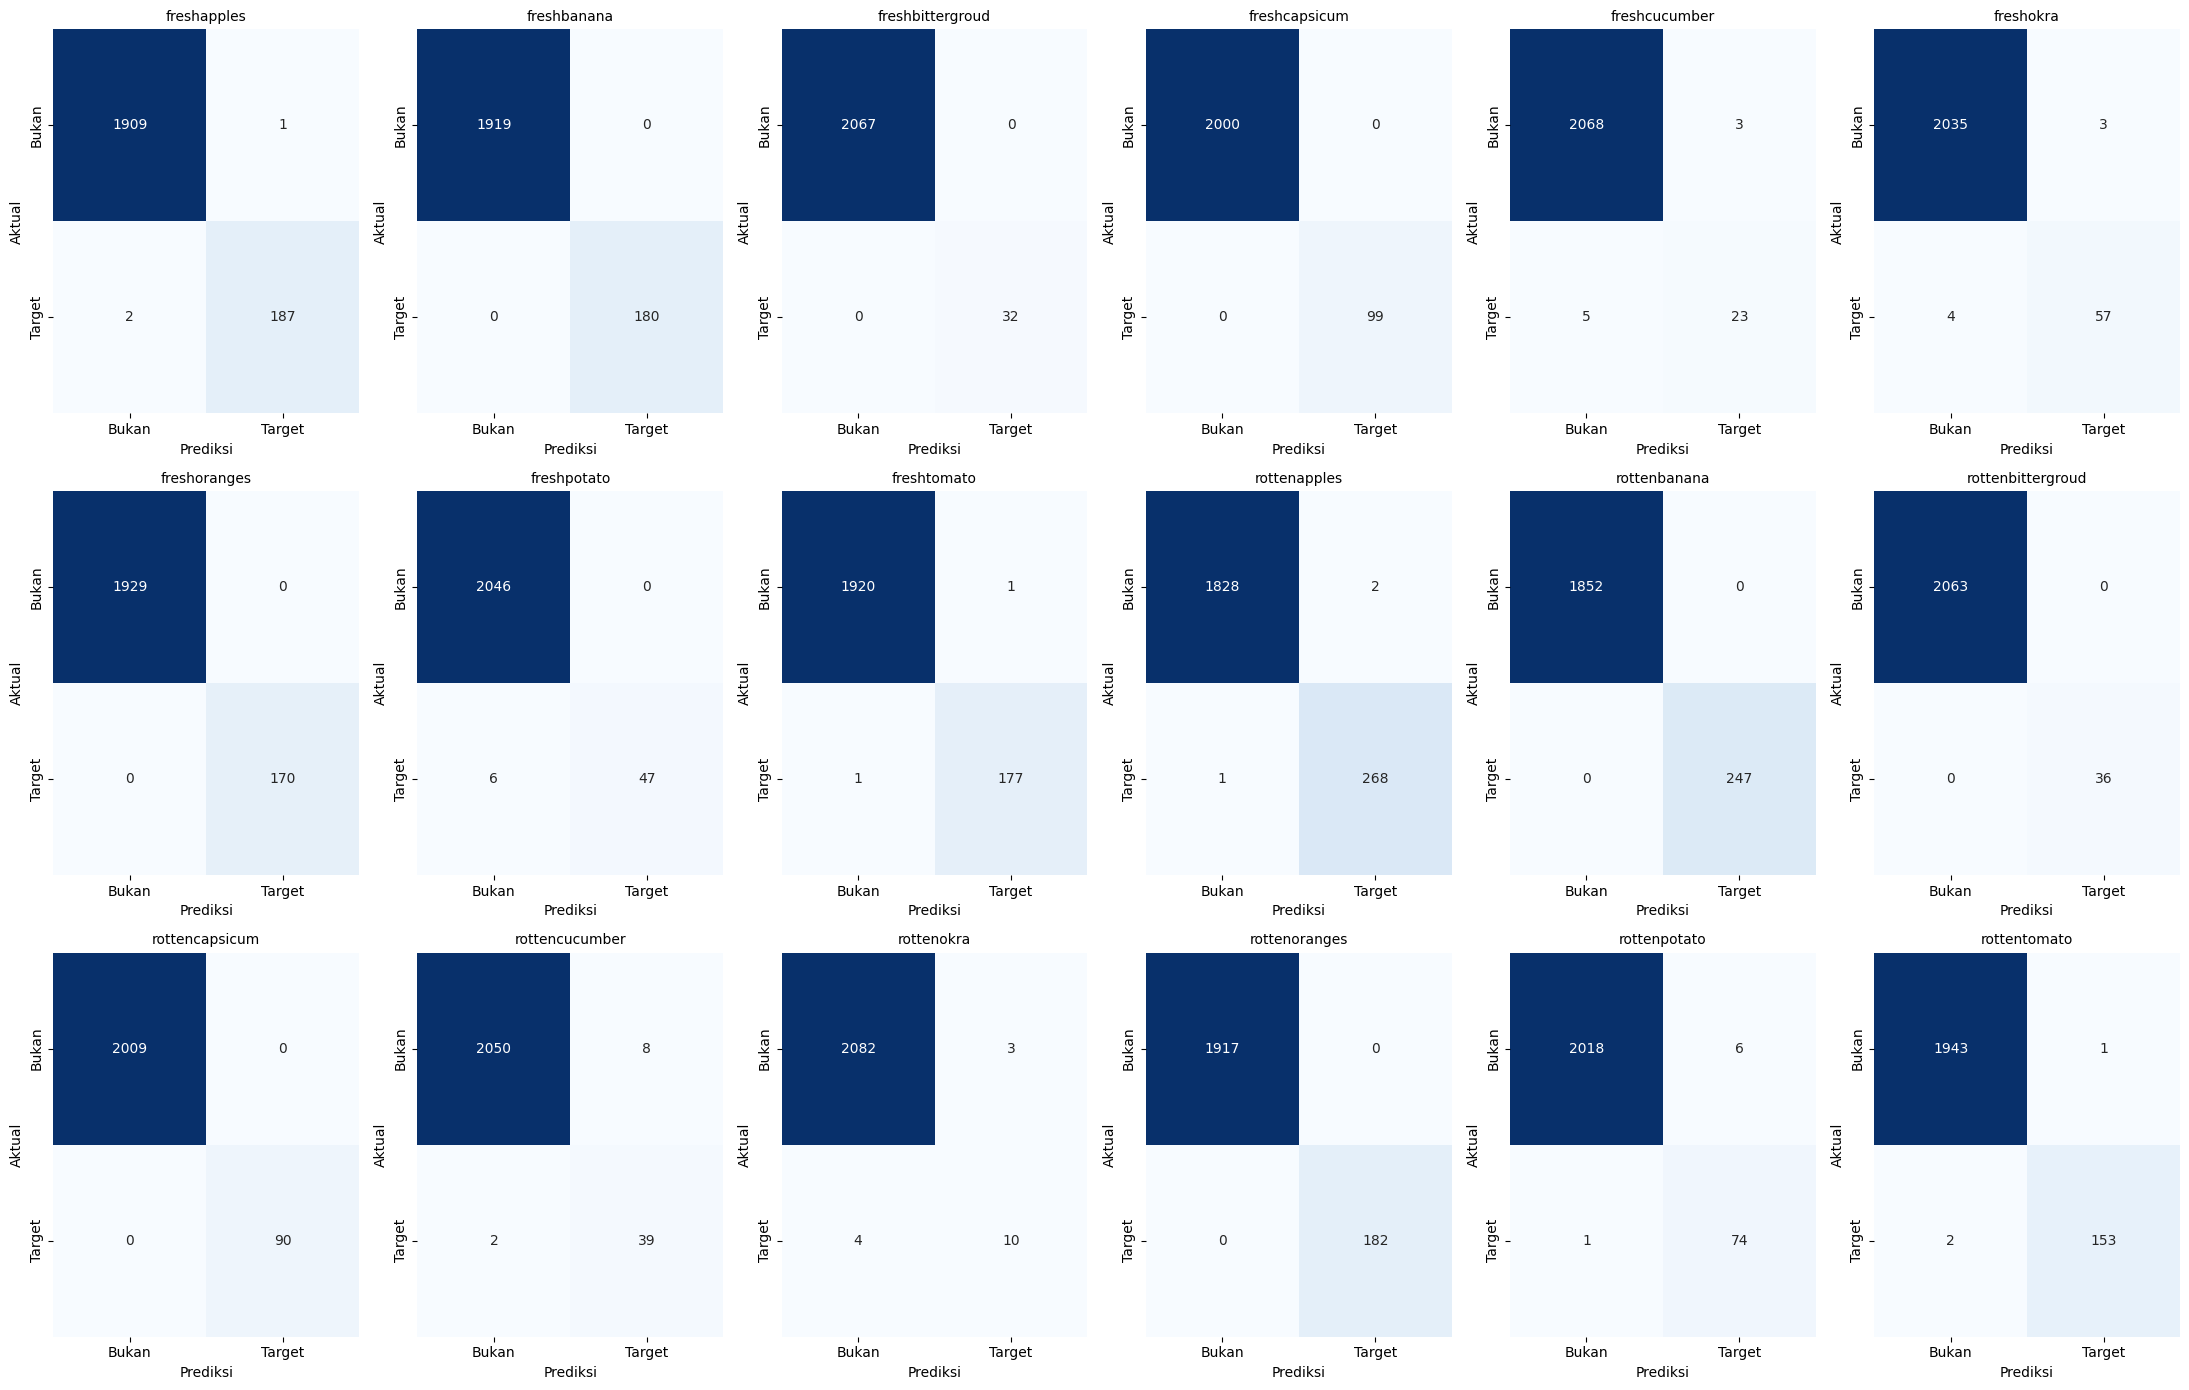

In [21]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
report_dict = classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys()), output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report['accuracy'] = df_report['recall']
df_report = df_report[['precision', 'recall', 'f1-score', 'accuracy', 'support']]
print("===========================================================================")
print("CLASSIFICATION REPORT DETIL PER KELAS")
print("===========================================================================")
print(df_report.round(2).to_string())
print("===========================================================================")
class_names = list(test_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(3, 6, figsize=(22, 14))
axes = axes.flatten()
for i in range(len(class_names)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    cm_binary = [[tn, fp], [fn, tp]]
    sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Bukan', 'Target'], yticklabels=['Bukan', 'Target'])
    axes[i].set_title(f'{class_names[i]}', fontsize=10)
    axes[i].set_ylabel('Aktual')
    axes[i].set_xlabel('Prediksi')
plt.tight_layout()
plt.show()

### **Uji Coba Prediksi dengan Gambar yang Diunggah**

In [22]:
import pandas as pd
history_df = pd.DataFrame(columns=[
    'Waktu Prediksi', 'File Gambar', 'Kelas Diprediksi',
    'Nama Komoditas', 'Status Kesegaran', 'Tingkat Keyakinan (%)', 'Waktu Inferensi (ms)'
])

Silakan unggah gambar (.png, .jpg, atau .jpeg)


Saving S784.png to S784.png


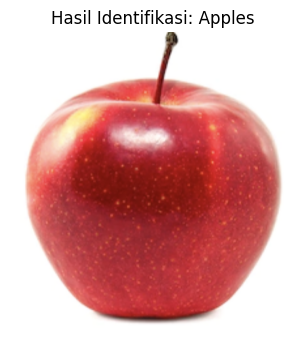


          HASIL IDENTIFIKASI          
Nama Komoditas      : Apples
Status Kesegaran    : Segar
Confidence Score    : 99.50%
Inference Time      : 20528.27 ms


In [24]:
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import time
def proses_dan_validasi_gambar(filename):
    try:
        img = Image.open(filename).convert('RGB')
        return img
    except FileNotFoundError:
        print(f"[ERROR] File gambar tidak ditemukan: {filename}")
        return None
    except Exception as e:
        print(f"[ERROR] Gagal memproses gambar {filename}: {e}")
        return None
print("Silakan unggah gambar (.png, .jpg, atau .jpeg)")
uploaded = files.upload()
if uploaded:
    filename = next(iter(uploaded.keys()))
    processed_img = proses_dan_validasi_gambar(filename)
    if processed_img is not None:
        img_resized = processed_img.resize((224, 224))
        img_array = img_to_array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        start_time = time.time()
        predictions = model.predict(img_array, verbose=0)
        end_time = time.time()
        inference_time = (end_time - start_time) * 1000
        highest_prob_idx = np.argmax(predictions[0])
        confidence_score = predictions[0][highest_prob_idx] * 100
        class_labels = list(train_generator.class_indices.keys())
        predicted_class_name = class_labels[highest_prob_idx]
        if 'fresh' in predicted_class_name:
            freshness_status = 'Segar'
            commodity_name = predicted_class_name.replace('fresh', '').capitalize()
        elif 'rotten' in predicted_class_name:
            freshness_status = 'Busuk (Tidak Segar)'
            commodity_name = predicted_class_name.replace('rotten', '').capitalize()
        else:
            freshness_status = 'Tidak Diketahui'
            commodity_name = predicted_class_name

        # ============================================================
        # MENAMPILKAN OUTPUT SESUAI PERMINTAAN
        # ============================================================
        plt.figure(figsize=(4, 4))
        plt.imshow(processed_img)
        plt.title(f"Hasil Identifikasi: {commodity_name}")
        plt.axis('off')
        plt.show()
        print("\n" + "="*40)
        print("          HASIL IDENTIFIKASI          ")
        print("="*40)
        print(f"Nama Komoditas      : {commodity_name}")
        print(f"Status Kesegaran    : {freshness_status}")
        print(f"Confidence Score    : {confidence_score:.2f}%")
        print(f"Inference Time      : {inference_time:.2f} ms")
        print("="*40)
    else:
        print("Gagal memproses gambar.")
else:
    print("Tidak ada file yang diunggah.")

# **Deployment**

In [26]:
import json
with open('class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

In [27]:
# ============================================================
# EXPORT MODEL TO H5
# ============================================================
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_filename = f'model_kesegaran_buah_{timestamp}.h5'
model.save(model_filename)
print(f"Model berhasil disimpan sebagai: {model_filename}")
print("File ini sekarang siap digunakan untuk tahap Deployment atau pengujian di aplikasi.")
from google.colab import files
files.download(model_filename)

Model berhasil disimpan sebagai: model_kesegaran_buah_20260705-082623.h5
File ini sekarang siap digunakan untuk tahap Deployment atau pengujian di aplikasi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>